In [1]:
# ===== BIBLIOTECAS =====
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ===== FUNÇÕES AUXILIARES =====
# Função para normalizar os valores dos pixel entre 0 e 255
def normalizeImage(image):
    # Pegando o máximo e mínimo
    maximum = np.max(image)
    minimum = np.min(image)
    # Realizando a normalização
    return 255.0 * (image - minimum) / (maximum - minimum)

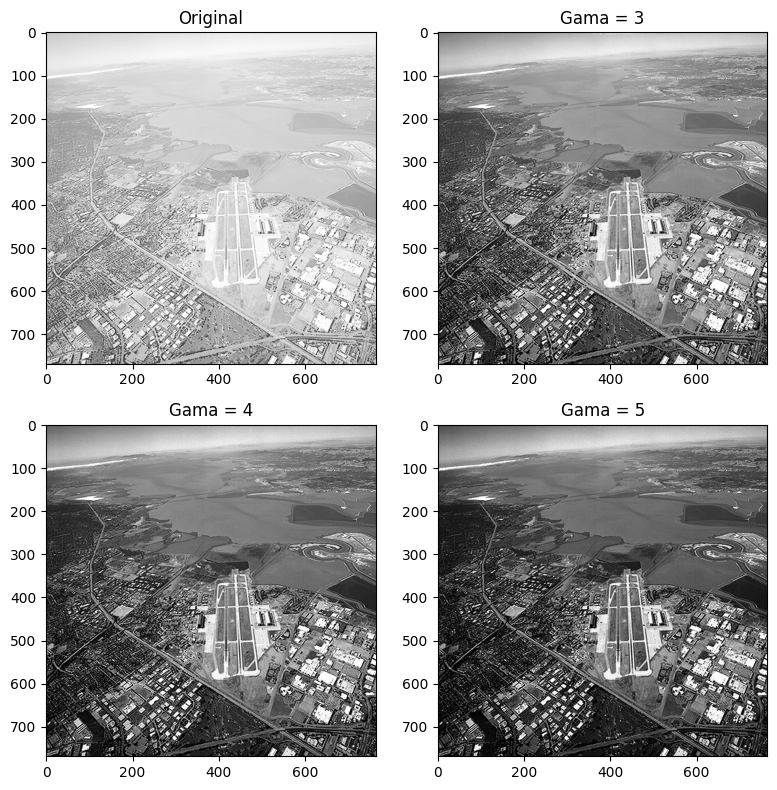

In [3]:
# === CÓDIGO PRINCIPAL =====

images = [] # Array com as imagens

# Carregar a imagem original, passando para escala de cinza e
# aumentando a capacitada de uint8 para uint64
images.append(cv.imread('./images/washed_out_aerial_image.tif'))
images[0] = cv.cvtColor(images[0], cv.COLOR_BGR2GRAY)
images[0] = images[0].astype(np.uint64)

# Array dos Gamas
gamas = [3, 4, 5]

# Aplicando o realce (Transformação de Potência) e 
# normalizando os valores para o intervalor [0, 255]
for i in range(3):
  images.append(images[0] ** gamas[i])
  images[i + 1] = normalizeImage(images[i + 1])

# Convertendo de BGR para RGB
for i in range(4):
  images[i] = cv.cvtColor(images[i].astype(np.uint8), cv.COLOR_GRAY2BGR)

# Criando grade 2 x 2 para plotar imagens
fig, axs = plt.subplots(2, 2, figsize = (8, 8))

# Titulos da imagens
titles = ['Original', 'Gama = 3', 'Gama = 4', 'Gama = 5']

# Definindo o local de cada imagem
for i in range(2):
  for j in range(2):
    k = 2 * i + j
    axs[i][j].imshow(images[k])
    axs[i][j].set_title(titles[k])

plt.tight_layout() # Evitando sobreposição

# Plotando as imagens e salvando o resultado
fig.savefig('./images/washed_out_aerial_image.png', dpi = 300, bbox_inches = 'tight')
plt.show()